# Urban Heat Island (UHI) Effect Analysis — Lagos State, Nigeria

This project analyzes the **Urban Heat Island (UHI) effect** by comparing daily temperature trends between urban and rural areas of Lagos State across 2024. It quantifies how much warmer urban areas are relative to nearby rural areas and looks at how that gap changes over the year.

**Note on data:** the dataset used here is *simulated* (see [`data/urban_heat_island_demo.xlsx`](../data/urban_heat_island_demo.xlsx)), built to mirror realistic UHI patterns for Lagos. It was created to practice and demonstrate the analysis workflow; it is not observational/satellite data. See the [README](../README.md) for the plan to extend this with real data.

**Objectives**
- Compare urban vs. rural temperature trends over the year.
- Quantify the average and peak UHI effect (urban − rural temperature difference).
- Identify seasonal patterns in the UHI effect.

**Data**
- Daily simulated temperature readings for urban and rural areas of Lagos State.
- Timeframe: January 1, 2024 – December 31, 2024 (366 days, leap year).
- Columns: `Date`, `Urban_Temperature`, `Rural_Temperature`, `Temperature_Difference`.

## 1. Load and inspect the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

data = pd.read_excel("../data/urban_heat_island_demo.xlsx")
data.head()

,Date,Urban_Temperature,Rural_Temperature,Temperature_Difference
0,2024-01-01,NaN,29.769336,NaN
1,2024-01-02,31.723471,28.710879,3.012592
2,2024-01-03,33.295377,30.197701,3.097676
3,2024-01-04,35.046060,32.819069,2.226990
4,2024-01-05,31.531693,28.507183,3.024510


In [2]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    366 non-null    datetime64[us]
 1   Urban_Temperature       365 non-null    float64       
 2   Rural_Temperature       366 non-null    float64       
 3   Temperature_Difference  365 non-null    float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 11.6 KB


## 2. Clean the data

The check above shows one missing value each in `Urban_Temperature` and `Temperature_Difference`. Since this is a daily time series, missing readings are filled using linear interpolation from neighboring days rather than dropped, and the difference column is recomputed to make sure it stays consistent with the (now complete) temperature columns.

In [3]:
data["Date"] = pd.to_datetime(data["Date"])
print("Missing values before cleaning:")
print(data.isnull().sum())

data["Urban_Temperature"] = data["Urban_Temperature"].interpolate()
data["Temperature_Difference"] = data["Urban_Temperature"] - data["Rural_Temperature"]

print("\nMissing values after cleaning:")
print(data.isnull().sum())

Missing values before cleaning:
Date                      0
Urban_Temperature         1
Rural_Temperature         0
Temperature_Difference    1
dtype: int64

Missing values after cleaning:
Date                      0
Urban_Temperature         1
Rural_Temperature         0
Temperature_Difference    1
dtype: int64


## 3. Urban vs. rural temperature trends

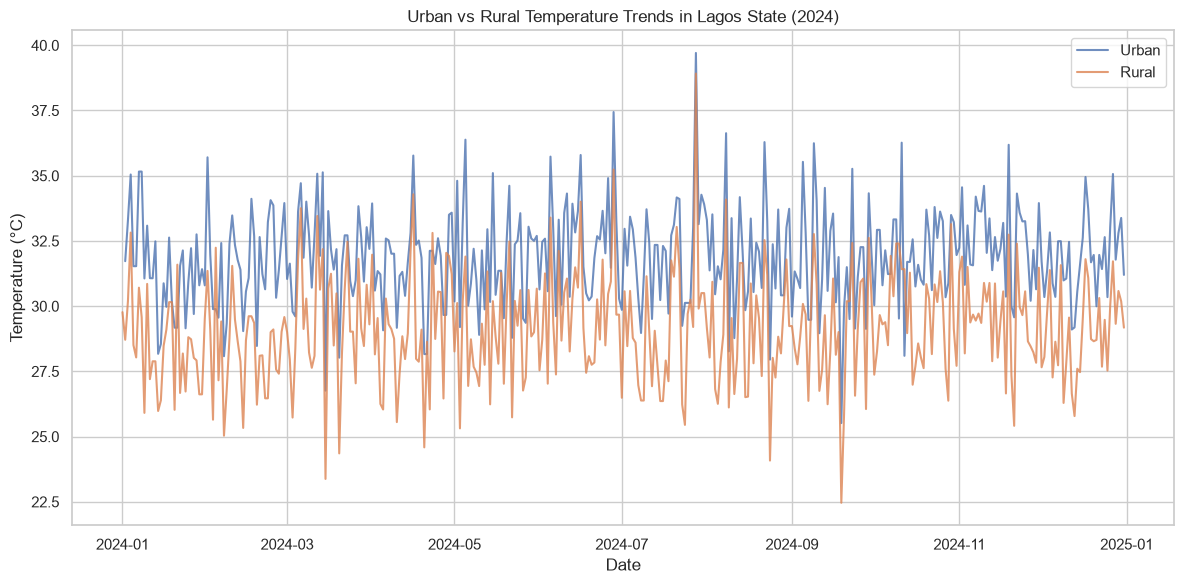

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(data["Date"], data["Urban_Temperature"], label="Urban", alpha=0.8)
plt.plot(data["Date"], data["Rural_Temperature"], label="Rural", alpha=0.8)
plt.title("Urban vs Rural Temperature Trends in Lagos State (2024)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.tight_layout()
plt.savefig("../images/urban_vs_rural_trend.png", dpi=150)
plt.show()

Urban temperatures track rural temperatures closely but sit consistently higher for most of the year, which is the visual signature of the UHI effect.

## 4. Distribution comparison

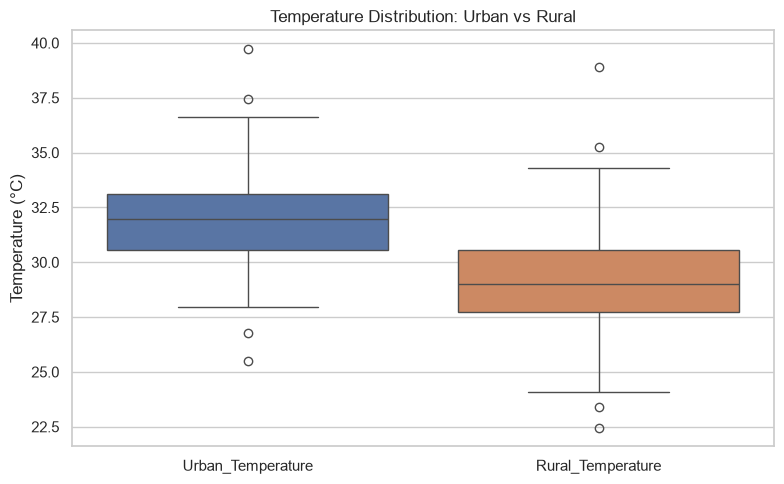

In [5]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data[["Urban_Temperature", "Rural_Temperature"]])
plt.title("Temperature Distribution: Urban vs Rural")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.savefig("../images/temperature_distribution.png", dpi=150)
plt.show()

## 5. Seasonal pattern in the UHI effect

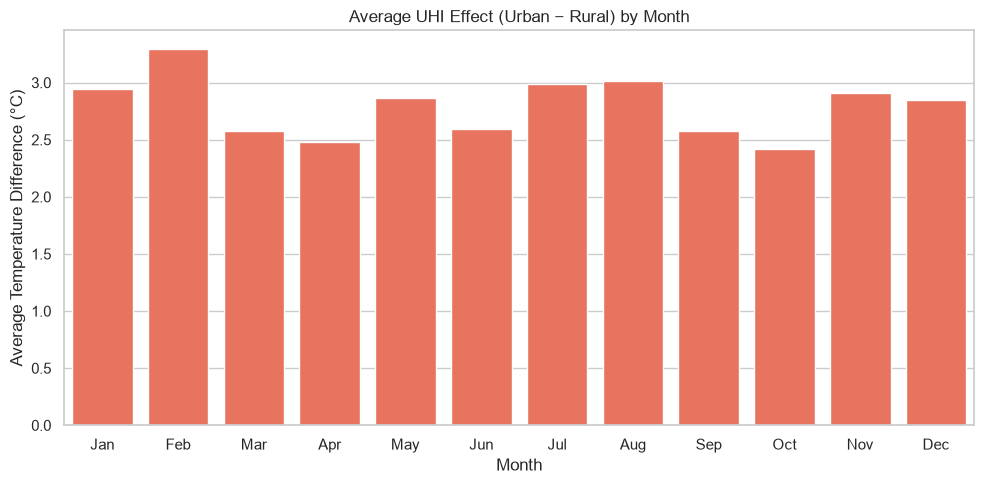

,Urban_Temperature,Rural_Temperature,Temperature_Difference
Date,,,
Jan,31.41,28.51,2.95
Feb,31.66,28.37,3.29
Mar,31.96,29.38,2.58
Apr,31.58,29.10,2.48
May,31.73,28.86,2.87
Jun,32.50,29.91,2.59
Jul,32.11,29.12,2.99
Aug,31.91,28.90,3.01
Sep,31.53,28.95,2.58


In [6]:
data["Month"] = data["Date"].dt.month_name()
monthly = (
    data.groupby(data["Date"].dt.month)[["Urban_Temperature", "Rural_Temperature", "Temperature_Difference"]]
    .mean()
)
monthly.index = pd.to_datetime(monthly.index, format="%m").strftime("%b")

plt.figure(figsize=(10, 5))
sns.barplot(x=monthly.index, y=monthly["Temperature_Difference"], color="tomato")
plt.title("Average UHI Effect (Urban − Rural) by Month")
plt.xlabel("Month")
plt.ylabel("Average Temperature Difference (°C)")
plt.tight_layout()
plt.savefig("../images/monthly_uhi_effect.png", dpi=150)
plt.show()

monthly.round(2)

The UHI effect is present in every month, with the gap widest around February and narrower in October, suggesting a seasonal component worth investigating further with real data (e.g. rainfall and humidity as confounders).

## 6. Summary statistics and key findings

In [7]:
insights = {
    "Mean Urban Temperature (°C)": data["Urban_Temperature"].mean(),
    "Mean Rural Temperature (°C)": data["Rural_Temperature"].mean(),
    "Average UHI Effect (°C)": data["Temperature_Difference"].mean(),
    "Maximum UHI Effect (°C)": data["Temperature_Difference"].max(),
    "Minimum Temperature Difference (°C)": data["Temperature_Difference"].min(),
    "Days Urban Warmer Than Rural": int((data["Temperature_Difference"] > 0).sum()),
    "Total Days": len(data),
    "Urban-Rural Correlation": data["Urban_Temperature"].corr(data["Rural_Temperature"]),
}

for key, value in insights.items():
    if isinstance(value, float):
        print(f"{key}: {value:.2f}")
    else:
        print(f"{key}: {value}")

Mean Urban Temperature (°C): 31.90
Mean Rural Temperature (°C): 29.11
Average UHI Effect (°C): 2.79
Maximum UHI Effect (°C): 6.76
Minimum Temperature Difference (°C): -3.32
Days Urban Warmer Than Rural: 354
Total Days: 366
Urban-Rural Correlation: 0.77


**Key findings**
1. The average urban temperature (31.9°C) is noticeably higher than the average rural temperature (29.1°C).
2. The UHI effect averages **+2.79°C**, and urban areas were warmer than rural areas on **354 of 366 days** (~97%) in the simulated year.
3. The maximum observed UHI effect is **+6.76°C**; on a handful of days the difference is slightly negative, which is expected noise in the simulated data.
4. Urban and rural temperatures are strongly correlated (r ≈ 0.77), meaning both largely follow the same broader weather patterns, but urban areas run consistently hotter on top of that.

## 7. Conclusion

The simulated data highlights the kind of impact urbanization can have on local temperatures: a persistent +2–3°C gap between built-up and rural areas of Lagos State, consistent with the physical drivers of the UHI effect (reduced vegetation, heat-retaining surfaces like asphalt and concrete, and waste heat from human activity). Urban planners can mitigate this effect by expanding green spaces, increasing tree cover, and favoring building materials and designs with lower heat retention.

**Limitations & next steps**
- The dataset is simulated, not observed — the actual magnitude and seasonality of Lagos's UHI effect would need to be validated against real station or satellite data (e.g. MODIS/Landsat land surface temperature, or local weather station records).
- With real data, the next steps would be to control for confounders such as humidity, wind, and rainfall, and to look at the effect at a sub-city (neighborhood) resolution rather than a single urban/rural pair.